In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, losses, metrics

In [2]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
# Para conocer más de la gpu disponible, podemos usar el siguiente comando:
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

In [4]:
#Tomar datos de un Dataset para no tomar ese pocotón de imagenes
fashion_mnist = tf.keras.datasets.fashion_mnist
#Lo puedo dividir de una vez en entramiento y prueba, ya que el dataset ya viene dividido en entrenamiento y prueba
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [5]:
#Declaramos las clases para poder verlas en la predicción y que no salgan solo los números
class_names = ['Camisa', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camiseta', 'Zapato deportivo', 'Bolso', 'Botas']

In [7]:
train_images.shape
#Vams a usar 60000 imágenes de entrenamiento y 10000 de prueba, cada imagen es de 28x28 píxeles.

(60000, 28, 28)

In [8]:
test_images.shape

(10000, 28, 28)

In [9]:
#Mirar las etiquetas
train_labels

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

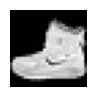

In [11]:
plt.figure(figsize=(1, 1)) #Pulgadas --> Una pulgada x una pulgada
plt.imshow(train_images[0], cmap='gray')
plt.axis('off')
plt.show()

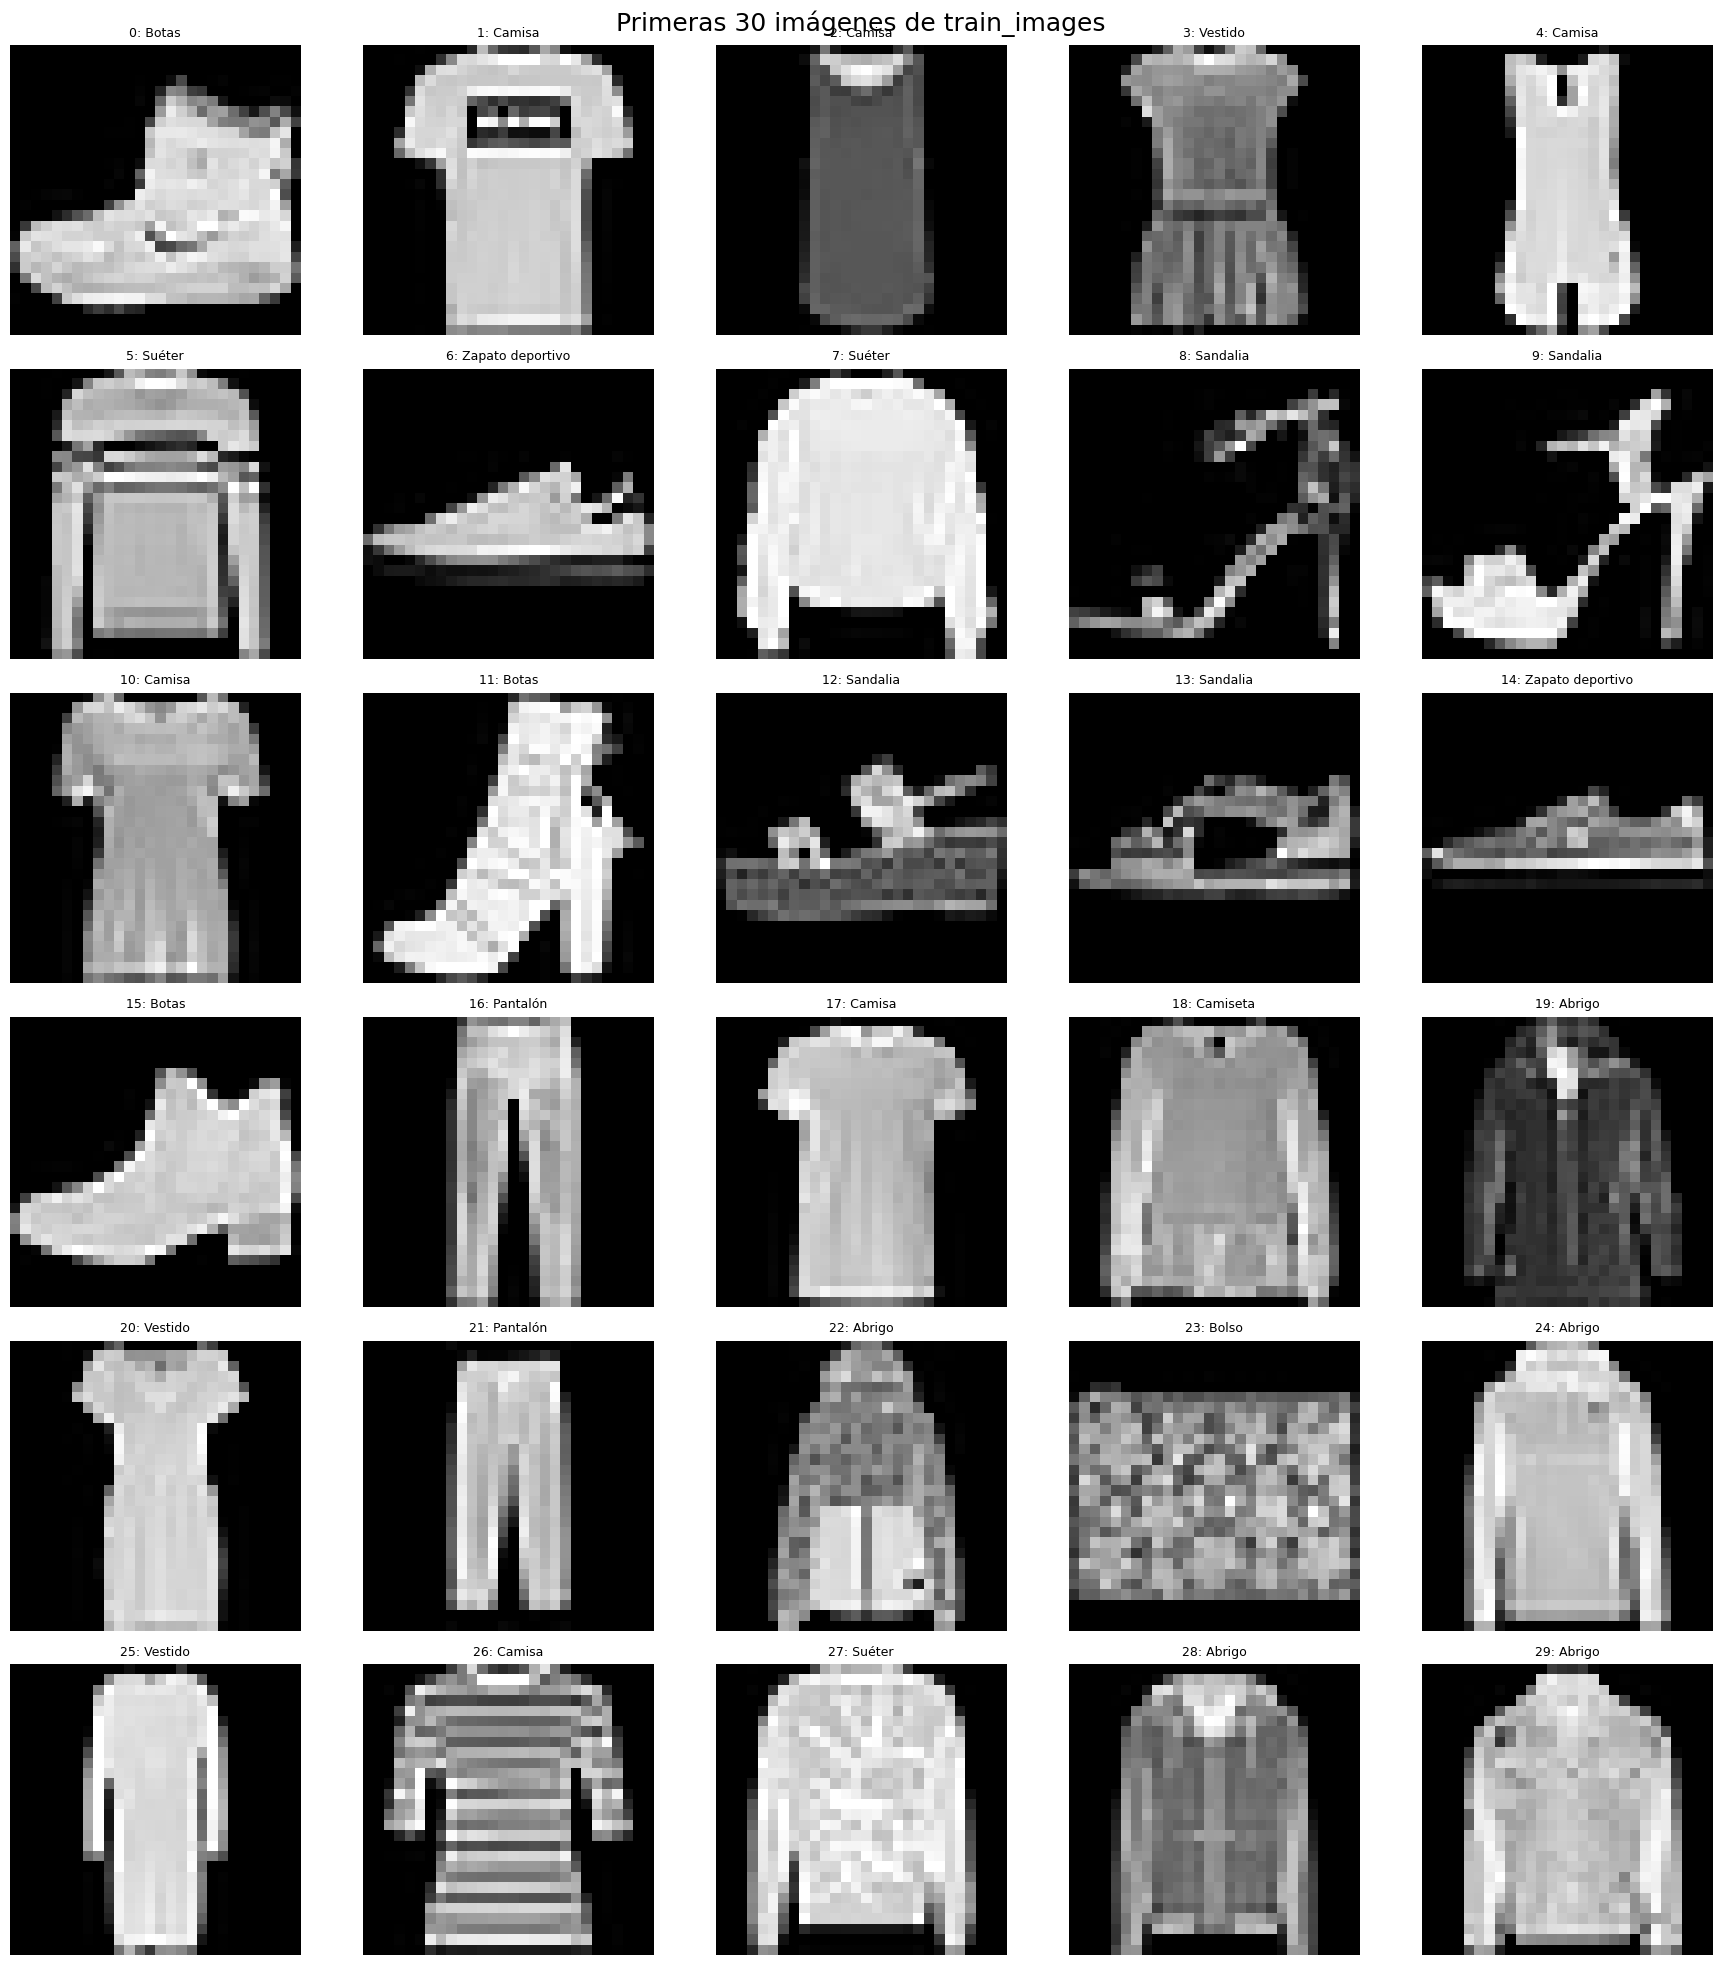

In [13]:
# Mostrar las primeras 30 imágenes de entrenamiento en 5 columnas y 6 filas
n_imagenes = 30
cols = 5
rows = 6

fig, axes = plt.subplots(rows, cols, figsize=(18, 20))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < n_imagenes:
        img = train_images[i]
        label = class_names[train_labels[i]]
        ax.imshow(img, cmap='gray')
        ax.set_title(f'{i}: {label}', fontsize=9)
        ax.axis('off')
    else:
        ax.axis('off')

fig.suptitle('Primeras 30 imágenes de train_images', fontsize=18, y=0.98)
plt.tight_layout()
plt.show()

In [ ]:
#Muestra los pixeles de la primera imagen de entrenamiento
train_images[0, :, :]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  

In [ ]:
#Como los valores de los pixeles van de 0 a 255, vamos a normalizar los datos para 
# que estén entre 0 y 1. Esto ayuda a que el entrenamiento sea más eficiente y rápido.
#LAS IMAGENES SE NORMALIZAN ASÍ
train_images = train_images / 255.0
test_images = test_images / 255.0

In [ ]:
#Prompt: Declarame una red neuronal secuencial cuyo input es una imagen de 28x28. 
# COloque un flatten o capa plana antes de las capas ocultas y luego cree 3 capas 
# ocultas de 64, 32 y 16 con función de activación relu. Y en la salida usamos softmax
# Red neuronal secuencial para Fashion MNIST
model = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()
#¿que es flaten?

In [ ]:
#Compilar
# Compilar el modelo
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Ver resumen de la compilación
model.summary()

In [ ]:
# Entrenar el modelo
history = model.fit(
    train_images, train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)